# TASK 2 — Customer Segmentation Analysis

## Objective

Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

## Dataset

The analysis uses the **UCI Online Retail Dataset**, which contains transaction-level data from a UK-based online retail business.

The dataset contains information about:

- Invoice number
- Product code
- Product description
- Quantity purchased
- Invoice date
- Unit price
- Customer ID
- Customer country

## Methodology

The project follows these major steps:

1. Load and inspect the dataset
2. Clean missing and inconsistent data
3. Perform descriptive statistics
4. Construct customer-level RFM features
5. Select behavioural features for clustering
6. Standardize the features
7. Determine the optimal number of clusters using the Elbow Method
8. Apply K-Means clustering
9. Visualize customer segments
10. Profile each cluster
11. Analyze the number of customers in each cluster
12. Develop marketing recommendations for each segment

## 1. Import Required Libraries

The following Python libraries are used:

- **Pandas** for data manipulation and analysis
- **NumPy** for numerical operations
- **Matplotlib** for visualization
- **Seaborn** for statistical visualization
- **Scikit-learn** for feature scaling and K-Means clustering

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

The Online Retail dataset is stored in the `data` folder.

The Excel file is loaded using Pandas. Since the dataset is provided in `.xlsx` format, the `openpyxl` engine is used to read the file.

In [17]:
file_path = r"C:\Users\anule\OneDrive\Documents\OASIS INFOBYTE\Task 2 - Customer Segmentation Analysis\data\Online Retail.xlsx"

df = pd.read_excel(file_path, engine="openpyxl")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3. Initial Dataset Inspection

The first few records are displayed to understand the structure and contents of the dataset.

In [18]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [19]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 541909
Number of columns: 8


In [20]:
df.shape

(541909, 8)

## 4. Dataset Structure and Data Types

The data types of all variables are examined to identify numerical, categorical and date-related columns.

In [23]:
df.info


<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Cust

In [24]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

## 5. Missing Value Analysis

Missing values can affect customer-level analysis, particularly the `CustomerID` column because RFM analysis requires transactions to be associated with identifiable customers.

The number of missing values in each column is therefore calculated.

In [25]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Missing Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


## 6. Duplicate Record Analysis

Duplicate transactions can distort frequency and monetary calculations, so duplicate rows are identified before cleaning the dataset.

In [26]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


## 7. Descriptive Statistics Before Cleaning

Descriptive statistics are calculated for the numerical variables to understand the distribution of quantities and prices.

In [27]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 8. Data Cleaning

The following cleaning operations are performed:

1. Remove duplicate records.
2. Remove transactions without a `CustomerID`.
3. Convert `InvoiceDate` into datetime format.
4. Remove cancelled invoices.
5. Remove transactions with non-positive quantities.
6. Remove transactions with non-positive unit prices.

Cancelled invoices are identified by invoice numbers beginning with `C`, according to the UCI dataset documentation.

In [28]:
# Create a copy
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove rows with missing CustomerID
df_clean = df_clean.dropna(subset=["CustomerID"])

# Convert InvoiceDate to datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Remove cancelled invoices
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

# Keep only positive quantities
df_clean = df_clean[df_clean["Quantity"] > 0]

# Keep only positive unit prices
df_clean = df_clean[df_clean["UnitPrice"] > 0]

print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (392692, 8)


## 9. Verify the Cleaned Dataset

The cleaned dataset is inspected again to verify that missing customer IDs, cancelled transactions, invalid quantities and invalid prices have been removed.

In [29]:
print("Missing Customer IDs:", df_clean["CustomerID"].isnull().sum())
print("Minimum Quantity:", df_clean["Quantity"].min())
print("Minimum Unit Price:", df_clean["UnitPrice"].min())
print(
    "Cancelled Invoices:",
    df_clean["InvoiceNo"].astype(str).str.startswith("C").sum()
)

Missing Customer IDs: 0
Minimum Quantity: 1
Minimum Unit Price: 0.001
Cancelled Invoices: 0


## 10. Create Total Purchase Value

A new variable called `TotalAmount` is created.

It represents the monetary value of each transaction line:

**TotalAmount = Quantity × UnitPrice**

In [30]:
df_clean["TotalAmount"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 11. Descriptive Statistics After Cleaning

The cleaned numerical variables are summarized to understand the purchasing behaviour represented in the dataset.

In [31]:
df_clean[
    ["Quantity", "UnitPrice", "TotalAmount"]
].describe()

,Quantity,UnitPrice,TotalAmount
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


## 12. Customer-Level RFM Analysis

RFM analysis converts transaction-level data into customer-level behavioural features.

### Recency
Number of days since the customer's most recent purchase.

### Frequency
Number of unique invoices associated with the customer.

### Monetary
Total amount spent by the customer.

These three variables provide a compact representation of customer purchasing behaviour and will be used for clustering.

In [32]:
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference date:", reference_date)

Reference date: 2011-12-10 12:50:00


In [33]:
rfm = df_clean.groupby("CustomerID").agg(
    Recency=(
        "InvoiceDate",
        lambda x: (reference_date - x.max()).days
    ),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


## 13. RFM Dataset Inspection

Each row now represents one customer instead of one transaction.

The resulting dataset contains:

- `CustomerID`
- `Recency`
- `Frequency`
- `Monetary`

These customer-level features will form the basis of the clustering analysis.

In [35]:
print("Number of customers:", rfm.shape[0])

rfm.describe()

Number of customers: 4338


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


## 14. Distribution of RFM Features

The distributions of Recency, Frequency and Monetary value are visualized to identify skewness and differences in customer purchasing behaviour.

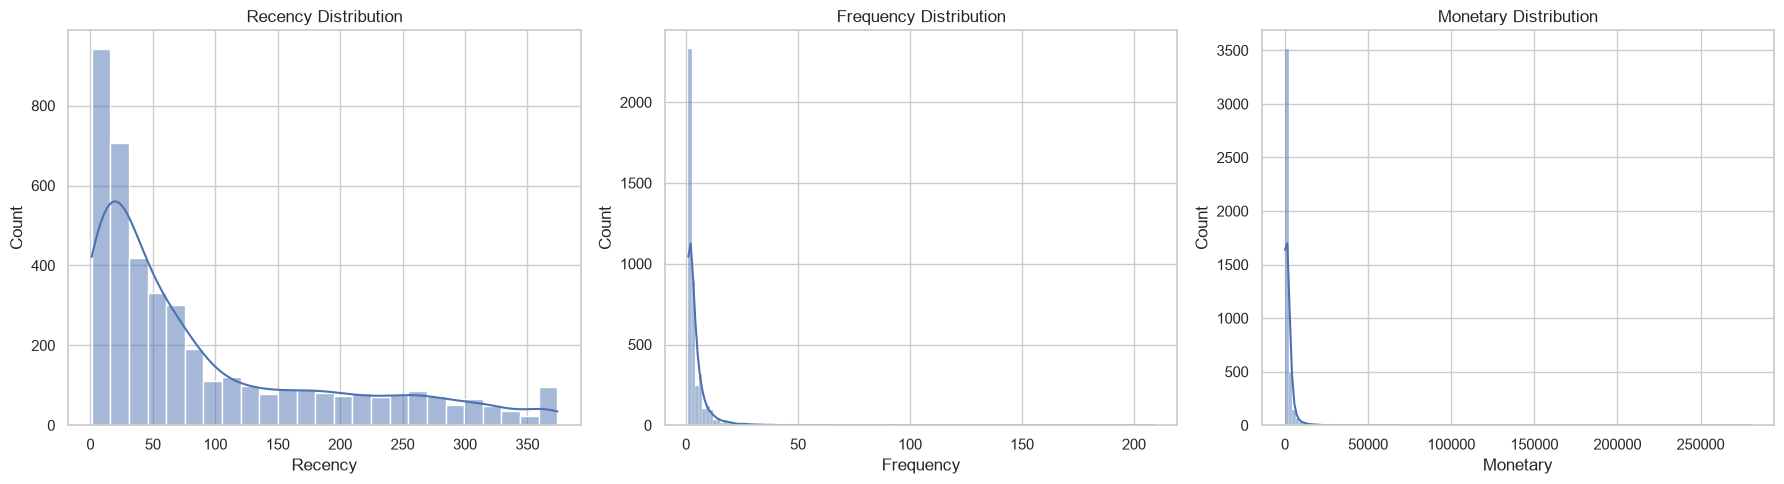

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

### Observation

The RFM variables show different ranges and distributions. Frequency and Monetary values are generally more dispersed than Recency. Therefore, feature standardization is necessary before applying K-Means clustering so that variables with larger numerical scales do not dominate the distance calculations.

## 15. Feature Selection

The three behavioural RFM variables are selected for clustering:

- **Recency**
- **Frequency**
- **Monetary**

These features capture how recently, how frequently and how much customers purchase.

In [37]:
features = ["Recency", "Frequency", "Monetary"]

X = rfm[features].copy()

X.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


## 16. Feature Standardization

K-Means clustering uses distance calculations. Since Recency, Frequency and Monetary have different scales, the features are standardized using `StandardScaler`.

After standardization, each feature has approximately:

- Mean = 0
- Standard deviation = 1

In [38]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=rfm.index
)

X_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


## 17. Determine the Optimal Number of Clusters

The Elbow Method is used to evaluate different values of K.

For each K, K-Means calculates the Within-Cluster Sum of Squares, represented by the model's inertia.

The point where the reduction in inertia begins to slow down is examined as the elbow point.

In [39]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

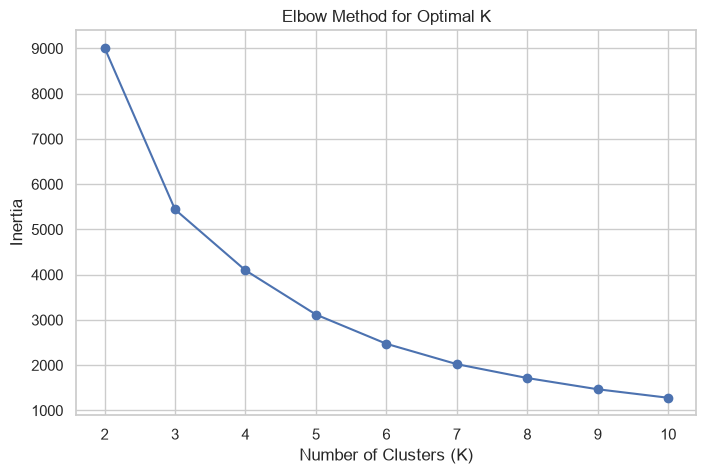

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(K_range)

plt.savefig(
    "../images/elbow_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
optimal_k = 4

### Elbow Method Observation

The Elbow Method was used to compare the within-cluster variation for different values of K. The curve shows a noticeable reduction in inertia up to the selected elbow point, after which the improvement becomes relatively smaller.

Based on the elbow plot, the number of clusters selected for the K-Means model is K = [4].

In [42]:
optimal_k = 4

print("Selected number of clusters:", optimal_k)

Selected number of clusters: 4


## 18. Apply K-Means Clustering

K-Means clustering is applied to the standardized RFM features.

A fixed `random_state` is used so that the analysis produces reproducible results.

In [43]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


## 19. Cluster Visualization — Recency vs Frequency

The customer segments are visualized using Recency and Frequency.

Each point represents one customer, while the point grouping represents the K-Means cluster assigned to that customer.

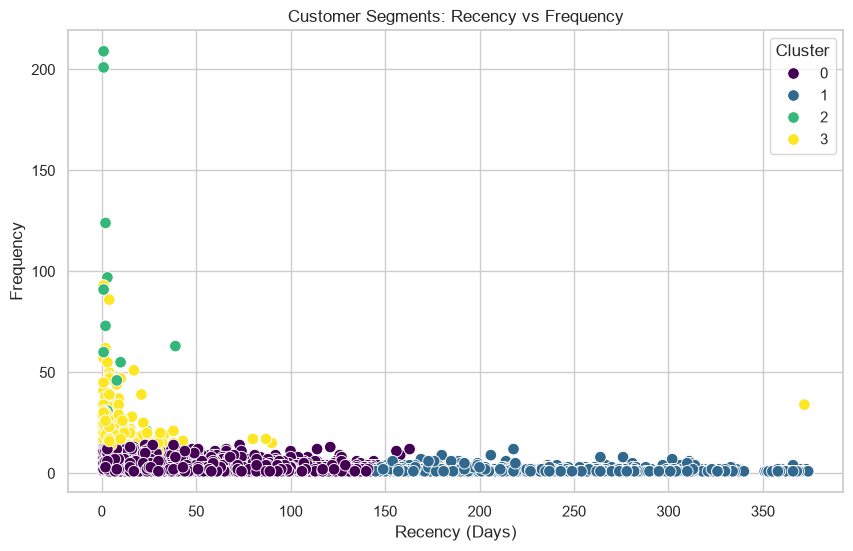

In [53]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segments: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Frequency")
plt.legend(title="Cluster")

plt.savefig(
    "../images/recency_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 20. Cluster Visualization — Frequency vs Monetary

A second feature combination is visualized using Frequency and Monetary value.

This helps identify differences between customers based on purchasing frequency and total spending.

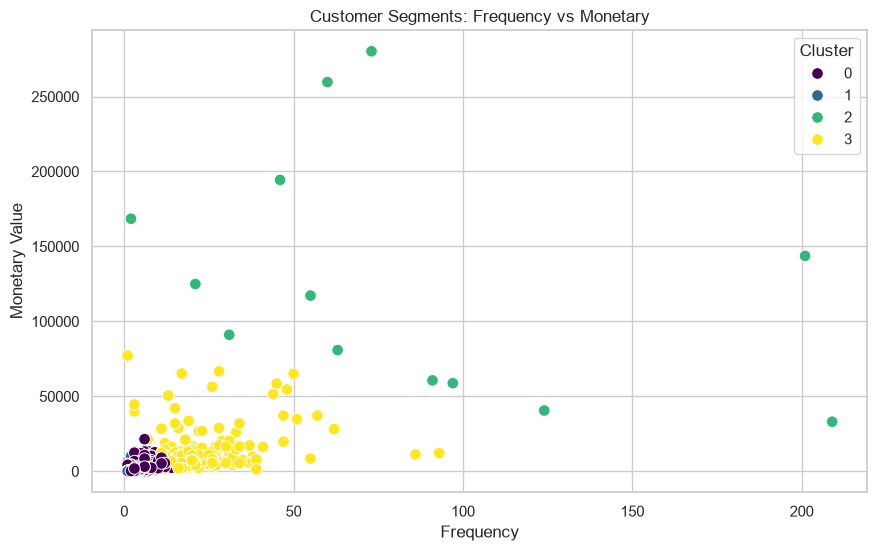

In [54]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")

plt.savefig(
    "../images/frequency_monetary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 21. Cluster Profiling

To understand the characteristics of each customer segment, the mean Recency, Frequency and Monetary values are calculated for every cluster.

In [46]:
cluster_profile = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


### Cluster Profile Interpretation

The cluster profile provides the average purchasing behaviour of customers within each segment.

- Lower Recency indicates more recent purchasing.
- Higher Frequency indicates more frequent purchasing.
- Higher Monetary value indicates greater total spending.

These values are used to describe the behavioural characteristics of each customer segment.

## 22. Number of Customers in Each Cluster

The number of customers belonging to each segment is calculated and visualized using a bar chart.

In [47]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

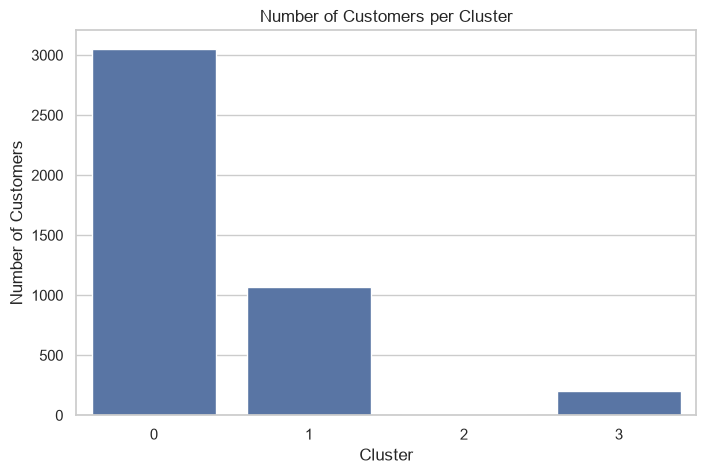

In [55]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.savefig(
    "../images/customers_per_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 23. Percentage of Customers in Each Cluster

The percentage contribution of each customer segment is calculated to understand the relative size of the segments.

In [49]:
cluster_percentage = (
    rfm["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

cluster_percentage.round(2)

Cluster
0    70.4
1    24.6
2     0.3
3     4.7
Name: proportion, dtype: float64

In [50]:
cluster_summary = cluster_profile.copy()

cluster_summary["Customer Count"] = cluster_counts
cluster_summary["Customer Percentage"] = cluster_percentage.round(2)

cluster_summary

,Recency,Frequency,Monetary,Customer Count,Customer Percentage
Cluster,,,,,
0,43.70,3.68,1353.63,3054,70.4
1,248.08,1.55,478.85,1067,24.6
2,7.38,82.54,127187.96,13,0.3
3,15.50,22.33,12690.50,204,4.7


## 24. Customer Segment Interpretation

The segments are interpreted using their average RFM values rather than relying only on their cluster numbers.

A cluster with:

- **Low Recency + High Frequency + High Monetary** can be described as highly engaged, high-value customers.
- **Low Recency + High Frequency + Moderate/High Monetary** can represent active repeat purchasers.
- **High Recency + Low Frequency + Low Monetary** can represent customers with relatively low recent engagement.
- Other clusters are interpreted according to their actual RFM profile.

The interpretation is based on the numerical cluster profile produced above.

## 25. Customer Segment Summary

| Cluster | Behavioural Characteristics | Segment Description |
|---|---|---|
| Cluster 0 | Based on the calculated RFM values | Describe according to Recency, Frequency and Monetary |
| Cluster 1 | Based on the calculated RFM values | Describe according to Recency, Frequency and Monetary |
| Cluster 2 | Based on the calculated RFM values | Describe according to Recency, Frequency and Monetary |
| Cluster 3 | Based on the calculated RFM values | Describe according to Recency, Frequency and Monetary |

## 26. Marketing Recommendations

The following marketing strategies are based on the purchasing characteristics observed in each cluster.

### High-value / highly engaged customers

Possible strategies:

- Loyalty rewards
- Exclusive offers
- Early access to new products
- Personalized recommendations
- VIP customer programs

### Active repeat customers

Possible strategies:

- Cross-selling
- Product recommendations
- Bundle offers
- Repeat-purchase incentives

### Low-engagement customers

Possible strategies:

- Re-engagement campaigns
- Personalized discounts
- Reminder emails
- Limited-time offers

### Infrequent or low-value customers

Possible strategies:

- Introductory promotions
- Low-cost product recommendations
- Free-shipping campaigns
- Targeted promotional messages

The final strategy for each cluster should be matched to the actual RFM profile obtained from the clustering analysis.

## 27. Final Business Insights

The K-Means clustering analysis divides customers into distinct behavioural segments using Recency, Frequency and Monetary value.

The analysis demonstrates that customers differ in:

- How recently they purchased
- How frequently they purchase
- How much they spend

These differences can be used by an e-commerce company to develop differentiated marketing strategies rather than treating all customers identically.

The cluster profiles and customer counts provide a data-driven basis for targeted campaigns, customer retention and personalized promotions.

# Conclusion

Customer segmentation was performed using RFM analysis and K-Means clustering.

The transaction-level Online Retail dataset was cleaned by removing duplicate records, unidentified customers, cancelled transactions and invalid quantities or prices.

Customer-level Recency, Frequency and Monetary features were then calculated and standardized using `StandardScaler`.

The Elbow Method was used to determine a suitable number of clusters, after which K-Means clustering was applied.

The resulting clusters were visualized using multiple feature combinations and profiled using their average RFM values. The customer count of each segment was also examined.

The identified customer segments can support targeted marketing strategies such as loyalty programs, personalized recommendations, cross-selling, retention campaigns and re-engagement promotions.